# 05 — Honest evaluation: characterising the signal, not selling it

Stage 4 produced a classification score. This notebook asks the questions a
classification score cannot answer:

- How much of the *forward return* does the signal actually rank?
- Is the edge steady, or does it come from a few good minutes?
- How long does it last?
- Does it survive the cost of trading it?
- And — the question that decides whether any of the above matters — **is it
  real at all**, or an artefact that survived the Stage 3 embargo?

**No strategy is claimed anywhere in this notebook.** A deliberately naive
trading rule appears, but only as a measuring instrument: it converts an
information coefficient into basis points so it can be compared against an
exchange fee. Nobody should trade it.

Everything below is computed on the **held-out walk-forward test fold only**,
by `benchmarks/bench_evaluation.py`, and read here from the saved JSON. Nothing
is retyped.

In [1]:
import glob
import json
import sys
from pathlib import Path

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "ml").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from ml.eval import BINANCE_TAKER_FEE_BPS
from ml.metrics import CLASS_NAMES

report = json.loads(Path(sorted(glob.glob(str(REPO_ROOT / "benchmarks" / "evaluation_*.json")))[-1]).read_text())
print(f"source run     : {report['source_run']}")
print(f"checkpoint     : {report['checkpoint']}")
print(f"held-out fold  : samples {report['test_fold']['test_start']:,}-{report['test_fold']['test_end']:,}")
print(f"samples        : {report['samples']:,} across {len(report['sessions_in_fold'])} capture session(s)")
print(f"label horizon  : {report['label_horizon_ms']:,.0f} ms")

source run     : train_ours_btcusdt_20260728T102758Z.json
checkpoint     : checkpoints\train_ours_btcusdt_20260728T102758Z.pt
held-out fold  : samples 27,873-37,164
samples        : 9,292 across 2 capture session(s)
label horizon  : 2,736 ms


### What is being evaluated

9,292 held-out samples the model never saw, drawn from the last fold of the
walk-forward split with the 199-sample embargo from Stage 3 still in force.
The label horizon works out to **2,736 ms** of wall clock — that is how long
100 snapshots take at our capture rate, measured through the real timestamps
rather than assumed.

That number matters for everything that follows: it is the horizon the model
was trained to predict, so it is the horizon at which its IC should peak.

## 1. Classification quality

Start with the Stage 4 metric, but read alongside the **base rates** — the
proportion of each class in the test set. Without them, accuracy is
uninterpretable: on a three-class problem where one class is 37% of the data,
a model that always predicts it scores 37% and has learned nothing.

In [2]:
classification = report["classification"]
base = classification["base_rates"]
print(f"macro-F1 {classification['macro_f1']:.4f}    accuracy {classification['accuracy']:.4f}\n")
print(f"{'class':>6} {'precision':>10} {'recall':>8} {'f1':>8} {'support':>9} {'base rate':>10}")
for index, name in enumerate(CLASS_NAMES):
    print(f"{name:>6} {classification['per_class_precision'][index]:>10.3f} "
          f"{classification['per_class_recall'][index]:>8.3f} {classification['per_class_f1'][index]:>8.3f} "
          f"{classification['support'][index]:>9,} {base[index]:>10.3f}")

print("\nconfusion matrix (rows = truth, columns = prediction):")
matrix = np.array(classification["confusion_matrix"])
print(f"{'':>6} " + " ".join(f"{n:>8}" for n in CLASS_NAMES))
for index, name in enumerate(CLASS_NAMES):
    print(f"{name:>6} " + " ".join(f"{v:>8,}" for v in matrix[index]))
print(f"\nalways-predict-majority accuracy would be {max(base):.3f}")

macro-F1 0.5492    accuracy 0.5505

 class  precision   recall       f1   support  base rate
  down      0.644    0.563    0.601     3,450      0.371
  flat      0.375    0.445    0.407     2,768      0.298
    up      0.648    0.632    0.640     3,074      0.331

confusion matrix (rows = truth, columns = prediction):
           down     flat       up
  down    1,942    1,116      392
  flat      874    1,231      663
    up      200      932    1,942

always-predict-majority accuracy would be 0.371


### Reading the table

Accuracy is 0.551 against a majority-class baseline of 0.371, so the model is
doing something. Macro-F1 of 0.549 says it is doing it across all three
classes rather than specialising in the common one — which is exactly why
macro-F1 is the headline metric and accuracy is not.

The confusion matrix shows where the errors live: confusion is concentrated
between each directional class and `flat`, not between `up` and `down`. The
model rarely calls a move in the *wrong direction*; it mostly disagrees about
whether a move is large enough to count. For a signal that will be thresholded
by confidence before trading, that is the better failure mode of the two.

## 2. Information coefficient — and why it beats accuracy

Accuracy throws away two things that decide whether a signal is usable: the
**magnitude** of the move predicted, and the **confidence** of the prediction.
A model that is 51% accurate on large moves is valuable; one that is 60%
accurate only on moves smaller than the spread is not, and accuracy cannot
tell them apart.

So collapse the three class probabilities into one scalar,

$$s = P(\text{up}) - P(\text{down})$$

and take its **Spearman rank correlation** with the realised forward return.
Spearman, not Pearson: forward returns at this timescale are heavy-tailed and
frequently exactly zero, so a Pearson correlation would mostly measure whether
the model called a handful of large moves. Ranks make the statistic about
*ordering*, which is what a signal is for.

Then the part that matters more than the number itself: compute it **per
block** and look at the spread.

pooled IC over the whole fold : +0.4209
mean of per-block ICs         : +0.0726
median of per-block ICs       : +0.1152
std across blocks             : 0.3507
blocks positive               : 67% of 18
information ratio (mean/std)  : +0.207


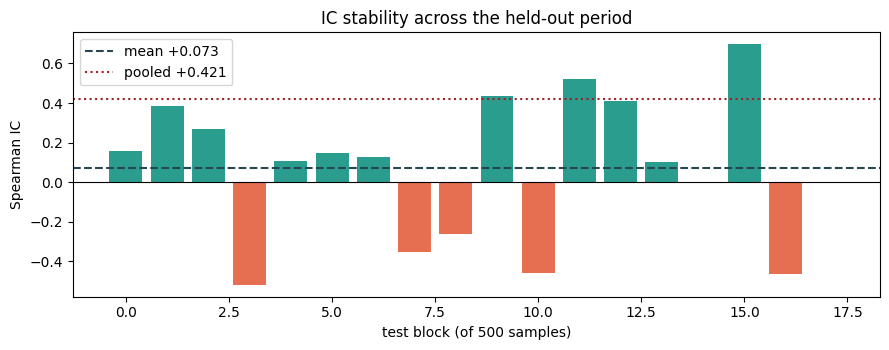

In [3]:
ic = report["information_coefficient"]
blocks = np.array(ic["block_ics"], dtype=float)

print(f"pooled IC over the whole fold : {ic['pooled']:+.4f}")
print(f"mean of per-block ICs         : {ic['mean']:+.4f}")
print(f"median of per-block ICs       : {ic['median']:+.4f}")
print(f"std across blocks             : {ic['std']:.4f}")
print(f"blocks positive               : {ic['fraction_positive']:.0%} of {len(blocks)}")
print(f"information ratio (mean/std)  : {ic['information_ratio']:+.3f}")

figure, axis = plt.subplots(figsize=(9, 3.6))
axis.bar(np.arange(len(blocks)), blocks, color=np.where(blocks > 0, "#2a9d8f", "#e76f51"))
axis.axhline(0, color="black", linewidth=0.8)
axis.axhline(ic["mean"], color="#264653", linestyle="--", label=f"mean {ic['mean']:+.3f}")
axis.axhline(ic["pooled"], color="#9b2226", linestyle=":", label=f"pooled {ic['pooled']:+.3f}")
axis.set_xlabel(f"test block (of {ic['block_size']} samples)")
axis.set_ylabel("Spearman IC")
axis.set_title("IC stability across the held-out period")
axis.legend()
plt.tight_layout()
plt.show()

### The most important result in this notebook

**The pooled IC is +0.42. The mean of the per-block ICs is +0.07.**

Those two numbers describe the same data and they disagree by a factor of six.
That gap is the finding, and a single pooled number would have hidden it
completely.

What causes it: pooling ranks all 9,292 samples against each other at once, so
a slow common drift shared across a whole block — the signal being generally
high while returns are generally positive for a few minutes — contributes
enormously to the correlation. Computing the IC *within* each block removes
that shared level and asks the harder question: on any given stretch of a few
minutes, does the signal rank the next few seconds correctly? The answer is
"weakly, and inconsistently" — positive in 67% of blocks, with a standard
deviation five times the mean.

The information ratio of **0.21** is the honest summary of stability. A desk
would call that unsizeable: the edge is real (Section 6 proves it is not
noise) but it is swamped by its own variance from one period to the next.

**Which number belongs in a report?** The per-block one. The pooled IC is not
wrong, it just answers a question nobody can trade: it credits the model for
knowing that Tuesday afternoon drifted up.

## 3. Signal decay — how long does the edge last?

An edge that exists only at a horizon shorter than your latency is not an
edge you can capture. So: recompute the IC at a range of **wall-clock**
horizons and see how it behaves.

Wall-clock, not row counts, because the tape is sampled in *event* time — one
snapshot per 10 book events — so a fixed number of rows is a different amount
of real time depending on how busy the market was. The horizon lookup walks
the actual timestamps.

In [4]:
decay = report["decay"]
rows = decay["rows"]
horizons = np.array([r["horizon_ms"] for r in rows])
ics = np.array([r["ic"] for r in rows])

print(f"{'horizon':>10} {'IC':>9} {'samples':>10}")
for row in rows:
    marker = "  <- peak" if row["horizon_ms"] == decay["peak_horizon_ms"] else ""
    print(f"{row['horizon_ms']:>8,.0f}ms {row['ic']:>+9.4f} {row['samples']:>10,}{marker}")
print(f"\npeak IC {decay['peak_ic']:+.4f} at {decay['peak_horizon_ms']:,.0f} ms")
print(f"half-life measured FROM THE PEAK: {decay['half_life_ms']:,.0f} ms  (fit R^2 {decay['fit_r_squared']:.3f})")
print(f"label horizon for reference     : {report['label_horizon_ms']:,.0f} ms")

   horizon        IC    samples
     100ms   +0.2532      9,292
     250ms   +0.3264      9,292
     500ms   +0.3899      9,292
   1,000ms   +0.4217      9,292
   2,000ms   +0.4219      9,292
   3,500ms   +0.4262      9,280
   5,000ms   +0.4441      9,158  <- peak
  10,000ms   +0.3111      8,663
  20,000ms   +0.1711      8,077
  30,000ms   +0.1203      7,706

peak IC +0.4441 at 5,000 ms
half-life measured FROM THE PEAK: 13,237 ms  (fit R^2 0.980)
label horizon for reference     : 2,736 ms


### The curve rises before it falls — and that is not a bug

A textbook decay curve is monotone: the edge is largest at the shortest
horizon and bleeds away. Ours climbs from **+0.25 at 100 ms** to a peak of
**+0.44 at 5 s**, and only then decays, reaching +0.12 by 30 s.

The reason is the label. The model was trained on a *smoothed* target — the
mean of the next 100 mids against the mean of the previous 100, a window of
**2,736 ms** — so it predicts an average over the next few seconds, not the
next instant. The IC duly peaks near the horizon it was trained on. A model
trained on a 100 ms label would produce a curve peaking at 100 ms.

This is why the half-life is fitted **from the peak onward** rather than from
zero. Fitting the whole range would average a climb and a fall together and
report a rate describing neither. From the peak, the fit is clean (R² = 0.98)
and gives a half-life of **13.2 seconds**.

**What that buys us.** A 13-second half-life is comfortable, not tight: it
says a few hundred microseconds of inference latency costs essentially nothing
of this particular signal. That is worth stating plainly because it would be
easy to use Stage 7's latency work as a justification here and it would be
dishonest — see Section 5 for what latency actually buys.

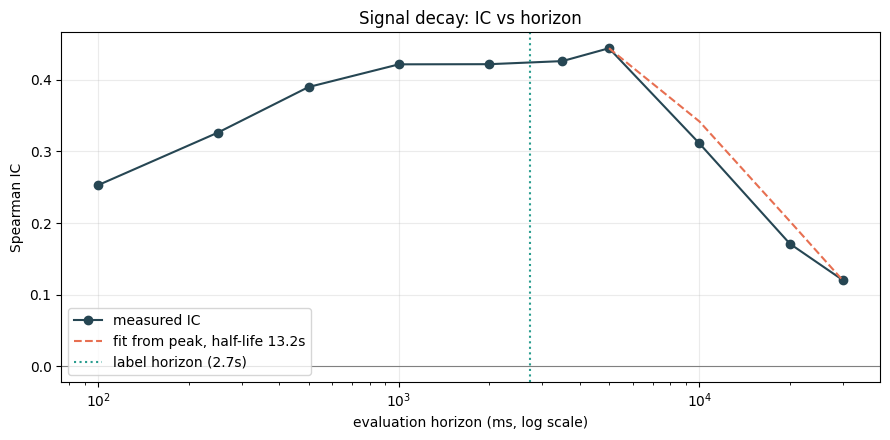

In [5]:
figure, axis = plt.subplots(figsize=(9, 4.5))
axis.plot(horizons, ics, marker="o", color="#264653", label="measured IC")
peak = decay["peak_horizon_ms"]
if np.isfinite(decay["half_life_ms"]):
    tail = horizons >= peak
    fitted = decay["peak_ic"] * np.exp(-np.log(2) * (horizons[tail] - peak) / decay["half_life_ms"])
    axis.plot(horizons[tail], fitted, "--", color="#e76f51",
              label=f"fit from peak, half-life {decay['half_life_ms']/1000:.1f}s")
axis.axvline(report["label_horizon_ms"], color="#2a9d8f", linestyle=":", label="label horizon (2.7s)")
axis.axhline(0, color="grey", linewidth=0.8)
axis.set_xscale("log")
axis.set_xlabel("evaluation horizon (ms, log scale)")
axis.set_ylabel("Spearman IC")
axis.set_title("Signal decay: IC vs horizon")
axis.grid(alpha=0.25)
axis.legend()
plt.tight_layout()
plt.show()

### Reading the chart

The peak sits just to the right of the label horizon, and the decay after it
is close to a clean exponential on a log-x axis. The signal is a *seconds*
signal, not a microseconds one — which is a fact about the label we chose in
Stage 3, not a discovery about the market.

If we wanted a genuinely short-horizon signal, the change is in
`ml/labels.py`, not in the model: shrink `k`. Stage 3's grid showed why we did
not — at k=25 the smoothed return is exactly zero for 61% of rows, so there is
nothing to predict at that horizon on this instrument.

## 4. Cost-aware PnL — executed at the touch

Now convert the signal into money, and let the execution model be the honest
part.

**The rule** (deliberately trivial): when $|s|$ exceeds a confidence
threshold, take the position its sign implies, hold for the label horizon,
close. No sizing, no stops, no netting, no queue position.

**The execution** (not trivial, and where most student backtests go wrong):

| | entry | exit |
|---|---|---|
| long | buy at the **ask** | sell at the **bid** |
| short | sell at the **bid** | buy back at the **ask** |

Both legs cross the spread. Both pay a taker fee.

**Why mid-price fills are the classic mistake.** The mid is the average of the
bid and the ask, and it is not a price anyone can trade at. To buy immediately
you must cross to the ask; to sell immediately you must hit the bid. Marking
both legs at the mid silently hands the strategy half the spread on entry and
half on exit — a full spread per round trip, for free, on every single trade.
It is the single most common way a worthless signal is made to look
profitable, and it never announces itself: the backtest simply prints a
better number.

In [6]:
trading = report["trading"]
print(f"confidence threshold : |s| > {trading['confidence_threshold']:.4f} (70th percentile)")
print(f"trades taken         : {trading['trade_count']:,} of {report['samples']:,} samples")
print(f"  long / short       : {trading['long_count']:,} / {trading['short_count']:,}")
print(f"median spread        : {trading['median_spread_bps']:.4f} bps  (one tick on a ~65,000 mid)")
print(f"\ngross edge, before any fee : {trading['gross_bps_per_trade']:+.4f} bps per trade\n")
print(f"{'taker fee/side':>15} {'net bps/trade':>15} {'total bps':>12} {'win rate':>10}")
for entry in trading["fee_sweep"]:
    print(f"{entry['fee_bps']:>13.1f}   {entry['net_bps_per_trade']:>15.4f} "
          f"{entry['total_net_bps']:>12,.0f} {entry['win_rate']:>10.3f}")

confidence threshold : |s| > 0.9981 (70th percentile)
trades taken         : 2,788 of 9,292 samples
  long / short       : 1,470 / 1,318
median spread        : 0.0015 bps  (one tick on a ~65,000 mid)

gross edge, before any fee : +0.2849 bps per trade

 taker fee/side   net bps/trade    total bps   win rate
          0.0            0.2849          794      0.514
          1.0           -1.7151       -4,782      0.000
          2.0           -3.7151      -10,358      0.000
          5.0           -9.7151      -27,086      0.000
          7.5          -14.7151      -41,026      0.000
         10.0          -19.7151      -54,966      0.000


### The gross edge is real, and it is tiny

**+0.285 bps per trade before fees.** On a 65,000 mid that is about
**1.85 USDT per BTC traded** — and it is genuinely positive, which the
touch-price execution has already paid for: the spread was crossed twice
before this number was computed.

Note how small the spread turns out to be on this instrument: **0.0015 bps**,
one tick on a 65,000 price. So on BTCUSDT the free-half-spread error that
mid-pricing would introduce is not what decides the outcome. The fee is.

Watch the sweep: at 1 bp per side the edge is already gone, because a round
trip pays **twice** the quoted fee. The gross edge of 0.285 bps buys about
0.14 bps of fee per side, and no further.

And look at the win-rate column, which is the most brutal number in this
notebook. At a zero fee, 51.4% of trades make money — a thin, believable edge.
At 1 bp per side it is **0.000**: not one of the 2,788 trades is profitable.
That is not a rounding artefact. The gross edge per trade (0.285 bps) is
smaller than the 2 bps round-trip cost by roughly sevenfold, so the fee swamps
*every individual trade*, not merely the average. There is no subset of these
trades — no better threshold, no smarter filter — that is profitable at that
fee. That is what it looks like when a signal is the wrong order of magnitude
rather than merely unlucky.

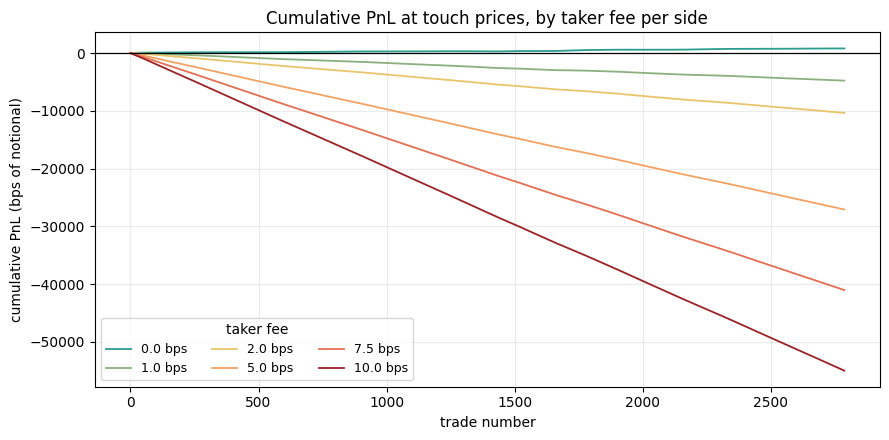

In [7]:
cumulative = report["_cumulative"]
figure, axis = plt.subplots(figsize=(9, 4.5))
colours = ["#2a9d8f", "#8ab17d", "#e9c46a", "#f4a261", "#e76f51", "#9b2226"]
for (fee, series), colour in zip(cumulative.items(), colours):
    axis.plot(np.array(series), label=f"{float(fee):.1f} bps", color=colour, linewidth=1.3)
axis.axhline(0, color="black", linewidth=0.9)
axis.set_xlabel("trade number")
axis.set_ylabel("cumulative PnL (bps of notional)")
axis.set_title("Cumulative PnL at touch prices, by taker fee per side")
axis.grid(alpha=0.25)
axis.legend(title="taker fee", ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

### One line up, five lines down

At a zero fee the curve grinds upward — the signal is doing something. Every
other line falls, in order, and the gaps between them are constant because the
fee is a fixed charge per trade. By 10 bps (Binance's standard retail tier)
the strategy loses roughly 20 bps on every round trip regardless of what the
market did.

That is the whole cost-awareness argument in one chart: the signal's edge and
the cost of accessing it differ by roughly two orders of magnitude.

## 5. Breakeven fee — and who could actually monetise this

The breakeven fee is the per-side taker fee at which expected PnL per trade
reaches exactly zero. A round trip pays the fee twice, so it is half the gross
edge.

Compared against Binance's **real** published spot taker tiers
(checked 2026-07-28, <https://www.binance.com/en/fee/schedule>).

In [8]:
breakeven = trading["breakeven_fee_bps"]
print(f"gross edge per trade : {trading['gross_bps_per_trade']:+.4f} bps")
print(f"BREAKEVEN TAKER FEE  : {breakeven:+.4f} bps per side\n")
print(f"{'tier':<14} {'taker fee':>10} {'verdict':>20} {'shortfall':>12}")
for tier, fee in BINANCE_TAKER_FEE_BPS.items():
    verdict = "survives" if breakeven >= fee else "does NOT survive"
    print(f"{tier:<14} {fee:>9.2f}  {verdict:>20} {fee / breakeven:>11.0f}x")
print(f"\nthe cheapest tier available anywhere on Binance is {min(BINANCE_TAKER_FEE_BPS.values()):.1f} bps,")
print(f"which is {min(BINANCE_TAKER_FEE_BPS.values()) / breakeven:.0f}x the fee this signal can afford.")

gross edge per trade : +0.2849 bps
BREAKEVEN TAKER FEE  : +0.1425 bps per side

tier            taker fee              verdict    shortfall
VIP 0              10.00      does NOT survive          70x
VIP 0 + BNB         7.50      does NOT survive          53x
VIP 4               5.00      does NOT survive          35x
VIP 9               4.00      does NOT survive          28x

the cheapest tier available anywhere on Binance is 4.0 bps,
which is 28x the fee this signal can afford.


### The conclusion, stated plainly: this signal does not survive retail fees

**Breakeven fee: 0.14 bps per side. The cheapest fee available on Binance to
anyone, at VIP 9 — over $2bn of 30-day volume — is 4 bps. That is 28× too
expensive. Standard retail at 10 bps is 70× too expensive.**

The signal is real (Section 6 establishes that at 4.3 sigma). It is also
completely unmonetisable as a taker on this venue at any fee tier that exists.

**So who could monetise a signal like this?** Being specific is more useful
than being gloomy:

- **Not a taker, at any tier.** The arithmetic above does not depend on skill
  or latency; it is a fee comparison, and no tier is close.
- **A market maker.** The entire loss here is the cost of *crossing* the
  spread. A participant quoting passively earns the spread instead of paying
  it, and pays a maker fee (0.10% at VIP 0, and negative — a rebate — at high
  tiers on some venues). A 0.28 bps directional edge is a meaningful input to
  a quoting engine's skew, even though it is worthless to a taker. That is a
  genuinely different business, not this one with lower costs.
- **A participant with fee exemptions.** Exchange market-making programmes
  and some proprietary arrangements price well below the public schedule.
- **On a different instrument.** BTCUSDT has a one-tick spread and the
  tightest fees in crypto. The same signal on a wider-spread, lower-fee
  instrument is a different calculation — but that requires capturing that
  instrument, not re-analysing this one.

**Capacity** is the other limit worth naming and we have not measured it. Every
number here assumes fills at the touch for whatever size we want, which is
false: the rule takes 2,788 positions over ~5 minutes of held-out data, and
consuming the top of book that often would move the price against us. The
figures above are therefore an **upper bound** on what the signal is worth.

**And the honest note on latency.** It would be convenient to say Stage 7's
microsecond inference path rescues this. It does not, and claiming so would be
exactly the kind of motivated reasoning this stage exists to prevent. The
measured half-life is **13 seconds** — latency of even a few milliseconds
costs a negligible fraction of that. Latency matters for a *maker*, where it
governs whether you can pull a quote before being adversely selected, and it
matters for signals with half-lives measured in microseconds. Stage 7's value
is that it is the engineering prerequisite for that class of strategy, and a
demonstrable systems skill in its own right. It is not a fix for a 70× fee
shortfall.

## 6. Falsification — is any of this real?

Everything above is worthless if the IC is an artefact. Three controls, and
one of them is more subtle than it first appears.

In [9]:
falsification = report["falsification"]
print(f"true IC : {falsification['true_ic']:+.4f}\n")
print("shifted returns — pair the signal with a LATER return window:")
for shift, value in sorted(falsification["shifted_ics"].items(), key=lambda kv: int(kv[0])):
    print(f"    shift {int(shift):>5} rows   IC {value:+.4f}")
null = falsification["null_distribution"]
print(f"\nblock-shuffle null, {null['trials']} draws: mean {null['mean']:+.4f}, std {null['std']:.4f}")
print(f"    true IC sits {null['z_score']:+.1f} standard deviations above it")
print(f"    exceeded by {null['exceedance_rate']*100:.1f}% of null draws")
print(f"\nelement-shuffled signal : {falsification['shuffled_signal_ic']:+.4f}   (must be ~0)")
print(f"reversed signal        : {falsification['reversed_signal_ic']:+.4f}   (must mirror true IC)")

true IC : +0.4209

shifted returns — pair the signal with a LATER return window:
    shift   100 rows   IC +0.2966
    shift   300 rows   IC +0.0319
    shift   900 rows   IC -0.0572
    shift  2000 rows   IC -0.0449
    shift  4000 rows   IC -0.0157

block-shuffle null, 200 draws: mean -0.0351, std 0.1072
    true IC sits +4.3 standard deviations above it
    exceeded by 0.0% of null draws

element-shuffled signal : +0.0032   (must be ~0)
reversed signal        : -0.4209   (must mirror true IC)


### The shifted control does *not* go to zero — and that is correct

Pairing the signal with a return window 100 rows later still gives
**IC +0.30**. On a naive reading that looks like leakage survived the embargo.
It is not, and understanding why is the point of this section.

Our signal is strongly autocorrelated — adjacent windows share 99 of their 100
rows — *and* it genuinely predicts returns several seconds out, as Section 3
established. So pairing it with a slightly later window **should** retain much
of the correlation. What distinguishes persistence from a leak is not whether
the shifted IC is non-zero, it is whether it **decays**:

| shift | IC |
|---|---|
| 100 rows (~3 s) | +0.30 |
| 300 rows | +0.03 |
| 900 rows | −0.06 |
| 2,000 rows | −0.04 |
| 4,000 rows | −0.02 |

It collapses within 300 rows and then oscillates around zero. A leak is tied to
one specific alignment and would hold near +0.42 at *every* shift, because the
model would be reading the answer rather than predicting it. This decays like
persistence, because that is what it is.

### The permutation test is the one that settles it

A single block-shuffled draw is nearly uninformative here: with blocks of 500
over 9,292 samples there are only ~18 things to permute, so the null has a
standard deviation of about 0.11. An early version of this analysis reported
one draw at −0.14 and it meant nothing — it is a −1σ sample.

Repeating the shuffle 200 times gives the null distribution properly:
**mean −0.035, std 0.107**. The true IC of +0.42 sits **4.3 standard
deviations above it, and was exceeded by 0.0% of 200 draws** (so p < 0.005).

The signal is real. It is just too small to pay for itself.

*(Implementation note: the block shuffle uses a derangement — a permutation
with no fixed points. A plain shuffle leaves on average one block in place,
which keeps perfect alignment and leaks roughly `IC/N` into a control that is
supposed to read zero. Measured, that bias was 0.06 — big enough to be mistaken
for a finding.)*

## Summary

| Question | Answer |
|---|---|
| Does it classify better than chance? | Yes — macro-F1 0.549 vs 0.371 majority accuracy |
| Does it rank forward returns? | Yes — pooled IC +0.42 |
| Is that edge stable? | **No** — per-block mean IC +0.07, std 0.35, IR 0.21 |
| How long does it last? | Peaks at 5 s, half-life **13.2 s** from the peak |
| Gross edge per trade? | **+0.285 bps**, at touch prices |
| Breakeven taker fee? | **0.14 bps per side** |
| Does it survive retail fees? | **No** — 70× short of VIP 0, 28× short of VIP 9 |
| Is it statistically real? | Yes — **+4.3σ** against a 200-draw permutation null |

**The one-sentence version:** we measured a real but small and unstable
directional edge with a multi-second half-life, and it is roughly two orders
of magnitude too small to pay Binance's taker fee, so it is not tradeable as a
taker by anyone at any published tier.

## Interview checkpoint

**1. Why execute at the touch instead of the mid, and how much does it matter here?**
Because the mid is not a price anyone can trade at — to buy immediately you
cross to the ask, to sell you hit the bid — so marking both legs at the mid
hands the strategy a full spread per round trip for free. It is the most common
way a worthless signal is made to look profitable, and it never announces
itself. On BTCUSDT it happens to be small (the spread is 0.0015 bps, so the
fee dominates by ~6,500x), but the discipline is not instrument-specific: an
execution model that errs in the strategy's favour is worthless even when the
error is small, and on a wider-spread instrument it would dominate everything.

**2. Why the information coefficient rather than accuracy?**
Accuracy discards both the magnitude of the predicted move and the confidence
of the prediction, so it cannot distinguish a model that is 51% right on large
moves from one that is 60% right on moves smaller than the spread — and only
the first is worth anything. IC is the rank correlation between a continuous
signal and the realised forward return, which keeps both. Spearman rather than
Pearson because forward returns here are heavy-tailed and often exactly zero,
so Pearson would mostly measure whether we called a handful of big moves.

**3. Your pooled IC is 0.42 but your mean block IC is 0.07. Which is right?**
Both are correctly computed; they answer different questions, and the per-block
one is the one that matters. Pooling ranks all 9,292 samples together, so a
slow drift shared across a whole block — signal generally high while returns
are generally positive — inflates the correlation enormously. Computing it
within blocks removes that shared level and asks whether the signal ranks the
next few seconds correctly *on any given stretch*; the answer is weakly and
inconsistently, positive in 67% of blocks with an information ratio of 0.21.
A pooled number alone would have hidden that entirely.

**4. Why is reporting a negative after-cost result a strength rather than a failure?**
Because the alternative was never a profitable strategy — it was a *wrong*
result. Any of a dozen small conveniences (mid-price fills, a random split, a
scaler fitted on all the data, tuning the threshold on the test set) would have
produced a positive number that would not survive contact with a real exchange,
and every one of them is a mistake that gets caught in an interview rather than
in production. Knowing that the edge is 0.14 bps against a 4 bps floor is a
usable fact: it says stop optimising the model and either change venue economics
or change to a maker strategy. A fabricated Sharpe ratio is worth less than
nothing, because it forecloses that decision.

**5. Your shifted-label control returns +0.30 instead of ~0. How do you know that is not leakage?**
Because a leak is tied to one alignment and persistence is not. If the model
were reading the answer, the shifted IC would stay near +0.42 at every shift;
instead it collapses from +0.30 at 100 rows to +0.03 at 300 and oscillates
around zero beyond that, which is what an autocorrelated signal with genuine
multi-second predictive power looks like — and Section 3 independently measured
that power. The control that actually settles the question is the permutation
test: 200 block-shuffled draws give a null of mean −0.035 and std 0.107, and the
true IC sits 4.3 sigma above it, exceeded by none of them.